
# Generation 3: Reading the Clinical Notes
"Vitals tell you numbers. Notes tell you the story. The best systems read both."

This notebook runs NBME dataset, fine-tunes ClinicalBERT, extracts attention weights, and saves the trained weights for local querying. Since this will be executed on a Kaggle environment, it is designed to run on a GPU.


In [1]:

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import getpass
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Ensure asset directories exist
os.makedirs("../assets/generation_3", exist_ok=True)


Using device: cuda



### 1. Data Loading & Preprocessing
We are using the **NBME - Score Clinical Patient Notes** dataset which contains patient history notes linked to different clinical cases.


In [4]:

# Load the local NBME dataset
nbme_path = "/kaggle/input/datasets/ashhadahmedkamran/nbmedataset/patient_notes.csv"

print("Loading NBME clinical notes...")
df_notes = pd.read_csv(nbme_path)
print(f"Successfully loaded {len(df_notes)} authentic clinical notes!")

# Rename the text column to match our workflow
df_notes.rename(columns={'pn_history': 'text'}, inplace=True)
df_notes['text'] = df_notes['text'].fillna("").astype(str)


Loading NBME clinical notes...
Successfully loaded 42146 authentic clinical notes!



### 2. Label Assignment
For this assignment, we need binary labels (Deterioration Risk vs Stable). 
We will create a text classification proxy target based on the `case_num` of each note. We will categorize half of the clinical cases (0-4) as "Stable" (0) and the other half (5-9) as "Deterioration Risk" (1).


In [5]:

# Create binary classification labels for demonstration
# 0 = Stable (Cases 0-4)
# 1 = Deterioration Risk / Active Monitoring (Cases 5-9)

df_notes['label'] = df_notes['case_num'].apply(lambda x: 1 if x >= 5 else 0)

# Drop exceptionally short notes
df_notes = df_notes[df_notes['text'].str.len() > 50]

texts = df_notes['text'].tolist()
labels = df_notes['label'].tolist()

print(f"Class Distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)


Class Distribution: {1: 21953, 0: 20192}



### 3. Tokenizer Configuration


In [10]:

model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(texts, labels, tokenizer, max_len, batch_size):
    ds = ClinicalNotesDataset(texts, labels, tokenizer, max_len)
    # Set num_workers=0 to avoid multiprocessing pickling issues with HF Tokenizers
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

BATCH_SIZE = 16
train_data_loader = create_data_loader(train_texts, train_labels, tokenizer, 512, BATCH_SIZE)
val_data_loader = create_data_loader(val_texts, val_labels, tokenizer, 512, BATCH_SIZE)



### 4. Training Loop Definition


In [11]:

def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    
    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return correct_predictions.double() / n_examples, np.mean(losses), all_preds, all_labels



### 5. Strategy 1: Frozen Base with Trainable Head


In [12]:

import time

print("--- Training Strategy 1: Frozen Base ---")
model_frozen = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Freeze BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

model_frozen = model_frozen.to(device)

optimizer_frozen = AdamW(model_frozen.classifier.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * 3
scheduler_frozen = get_linear_schedule_with_warmup(optimizer_frozen, num_warmup_steps=0, num_training_steps=total_steps)

start_time = time.time()
for epoch in range(3):
    train_acc, train_loss = train_epoch(model_frozen, train_data_loader, optimizer_frozen, device, scheduler_frozen, len(train_texts))
    val_acc, val_loss, preds, y_true = eval_model(model_frozen, val_data_loader, device, len(val_texts))
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
frozen_time = time.time() - start_time
print(f"Frozen Base Training Time: {frozen_time:.2f} seconds")

print("\nFrozen Base Classification Report:")
print(classification_report(y_true, preds, target_names=['Stable', 'Deterioration']))


--- Training Strategy 1: Frozen Base ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch 1 | Train Loss: 0.6817 | Val Loss: 0.6668 | Val Acc: 0.6319
Epoch 2 | Train Loss: 0.6663 | Val Loss: 0.6578 | Val Acc: 0.6559
Epoch 3 | Train Loss: 0.6611 | Val Loss: 0.6551 | Val Acc: 0.6638
Frozen Base Training Time: 4524.30 seconds

Frozen Base Classification Report:
               precision    recall  f1-score   support

       Stable       0.74      0.46      0.57      4038
Deterioration       0.63      0.85      0.73      4391

     accuracy                           0.66      8429
    macro avg       0.69      0.66      0.65      8429
 weighted avg       0.68      0.66      0.65      8429




### 6. Strategy 2: Full Fine-Tuning


In [13]:

print("\n--- Training Strategy 2: Full Fine-Tuning ---")
model_full = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, output_attentions=True)
model_full = model_full.to(device)

optimizer_full = AdamW(model_full.parameters(), lr=2e-5)
scheduler_full = get_linear_schedule_with_warmup(optimizer_full, num_warmup_steps=0, num_training_steps=total_steps)

start_time = time.time()
for epoch in range(3):
    train_acc, train_loss = train_epoch(model_full, train_data_loader, optimizer_full, device, scheduler_full, len(train_texts))
    val_acc, val_loss, preds_full, y_true_full = eval_model(model_full, val_data_loader, device, len(val_texts))
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
full_time = time.time() - start_time
print(f"Full Fine-Tuning Training Time: {full_time:.2f} seconds")

print("\nFull Fine-Tuning Classification Report:")
print(classification_report(y_true_full, preds_full, target_names=['Stable', 'Deterioration']))

# Save results
results = {
    "frozen_base_time_sec": frozen_time,
    "full_finetuning_time_sec": full_time
}
with open("../assets/generation_3/results.json", "w") as f:
    json.dump(results, f, indent=4)



--- Training Strategy 2: Full Fine-Tuning ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch 1 | Train Loss: 0.0302 | Val Loss: 0.0079 | Val Acc: 0.9983
Epoch 2 | Train Loss: 0.0020 | Val Loss: 0.0044 | Val Acc: 0.9988
Epoch 3 | Train Loss: 0.0004 | Val Loss: 0.0054 | Val Acc: 0.9991
Full Fine-Tuning Training Time: 12238.61 seconds

Full Fine-Tuning Classification Report:
               precision    recall  f1-score   support

       Stable       1.00      1.00      1.00      4038
Deterioration       1.00      1.00      1.00      4391

     accuracy                           1.00      8429
    macro avg       1.00      1.00      1.00      8429
 weighted avg       1.00      1.00      1.00      8429




### 7. Attention Visualization
Extracting the attention weights from the final layer to see what the model focuses on.


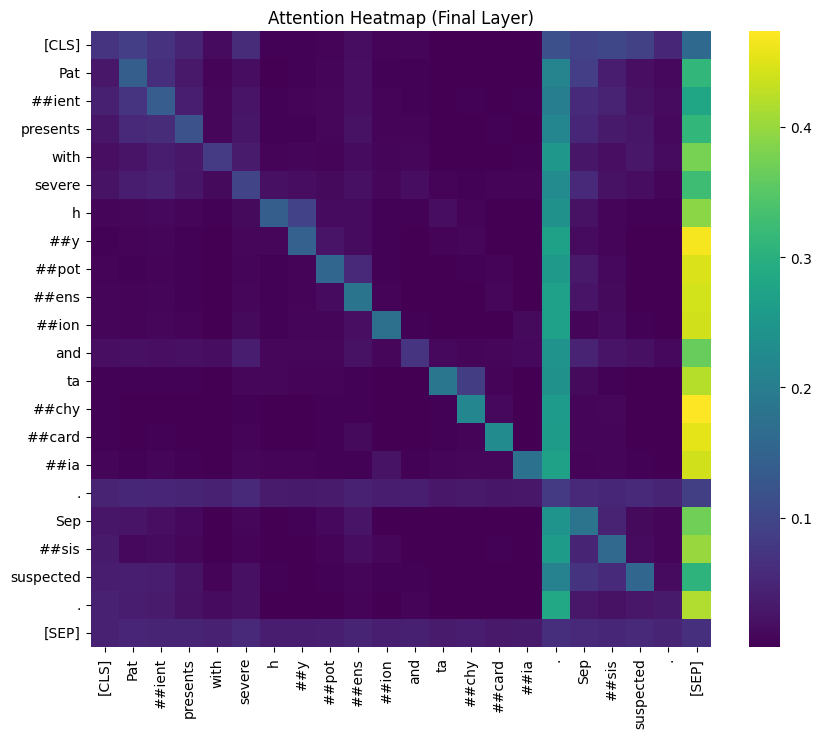

In [14]:

sample_text = "Patient presents with severe hypotension and tachycardia. Sepsis suspected."
encoding = tokenizer(sample_text, return_tensors='pt').to(device)

model_full.eval()
with torch.no_grad():
    outputs = model_full(**encoding)
    attentions = outputs.attentions # Tuple of 12 layers, each (batch, num_heads, seq_len, seq_len)

# Get the last layer attention
last_layer_attn = attentions[-1][0].cpu().numpy() # (num_heads, seq_len, seq_len)
# Average across all heads
avg_attn = np.mean(last_layer_attn, axis=0)

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

plt.figure(figsize=(10, 8))
sns.heatmap(avg_attn, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title("Attention Heatmap (Final Layer)")
plt.savefig("../assets/generation_3/attention_heatmap.png")
plt.show()



### 8. Save Model Weights
Save the fully fine-tuned model and tokenizer to the assets folder to download them locally.


In [1]:

model_save_path = "../assets/generation_3/clinicalbert_finetuned"
model_full.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model weights and tokenizer saved to {model_save_path}")


NameError: name 'model_full' is not defined


### 9. Local Inference / Query Cell
When you download `assets/generation_3/clinicalbert_finetuned` to your local machine, run the following code to query the LLM.


In [16]:

def query_local_model(text_note, model_path="../assets/generation_3/clinicalbert_finetuned"):
    # Load from local weights
    local_tokenizer = AutoTokenizer.from_pretrained(model_path)
    local_model = AutoModelForSequenceClassification.from_pretrained(model_path)
    
    inputs = local_tokenizer(text_note, return_tensors="pt", truncation=True, max_length=512)
    
    with torch.no_grad():
        outputs = local_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    stable_prob = probs[0][0].item()
    deterioration_prob = probs[0][1].item()
    
    print(f"--- Clinical Note Analysis ---")
    print(f"Note: {text_note}")
    print(f"Deterioration Risk: {deterioration_prob*100:.2f}%")
    print(f"Stable Probability: {stable_prob*100:.2f}%")
    
    if deterioration_prob > 0.5:
        print("\nAlert: High risk of patient deterioration detected.")
    else:
        print("\nPatient is stable.")

# Example Usage
# query_local_model("Patient is hypotensive, heart rate 130, unresponsive to fluids.")
